# Latent Dirichlet Allocation - Introduction
1. Each Document is a collection of topics
2. Each Topic is a collection of words

# Conceptual reason why LDA uses a Dirichlet Distribution
1. Assumption-1: each topic is a Dirichlet R.V. of the words present in the corpus
    1. words present in the corpus = list of all unique words found across all documents in the *training* corpus
    2. $k^{th}$ topic = $\sum\limits_{w \epsilon W} p_{w,k}$.w, s.t. $\sum\limits_{w \epsilon W}p_{k, w} = 1 \, ,\, \forall \,   k \,  \epsilon \,  [1,2,\cdots K]$ , where W: vocabulary(set of all words), w: $w^{th}$ word
    3. hence, each topic can be represented by a $W$ dimensional vector with all components being probability parameters.
    4. $k: [p_{1, k}, p_{2, k}, \cdots , p_{W, k}]$ is the dirichlet-distributed random vector.
    5. a topic: probability distribution over all words of the corpus.
2. Assumption-2: each document is a Dirichlet R.V. of the topics found from the first assumption
    1. $d^{th}$ document = $\sum\limits_{k \epsilon {1,2,\cdots ,K}} p_{k,d}$.k, s.t. $\sum\limits_{k \epsilon {1,2,\cdots ,K}}p_{k, d} = 1 \, ,\, \forall \,   d \,  \epsilon \,  [1,2,\cdots D]$ , where D: set of all documents used, k: $k^{th}$ topic
    2. hence, each document is represented by a $K$ dimensional vector with all components being probability parameters.
    3. $d: [p_{d, 1}, p_{d, 2}, \cdots , p_{d, K}]$ is the dirichlet-distributed random vector.
    4. a document: probability distribution over all topics modelled.

# Algorithm that uses Gibbs Sampling for learning hidden topic assignments
1. tokenize each document $d$
2. initialise the 3 hyperparameters: $\alpha, \beta, K$
    1. $K:$ total no. of topics to be modelled
    2. $\alpha: \alpha_{K\times 1}$  is the document-topic dirichlet prior concentration parameter vector.
    3. $\beta: \beta_{V\times 1}$  is the topic-word dirichlet prior concentration parameter vector.
    4. here, $V$: is the vocabulary size, i.e. the set of distinct tokens across all documents in the *training* corpus
2. for each document $d$, randomly assign each token of the token-sequence to one of the topics : $\{1,2,\cdots K\}$
    1. usually, a discrete uniform distribution is used, where $x = \{1,2,\cdots K\}$ all have a probability of $\dfrac{1}{K}$ rest all values have probability = 0.
    2. evaluate and store the following quantities:
        1. $n_{d,k}$: no. of tokens(token-occurences) in document $d$ that have been assigned to topic $k$.
        2. $N_d$: total no. of tokens(token-occurences) in document $d$.
        3. $n_{k, w}$: no. of times **across all documents** the token(token-occurence) $w$ is assigned to the topic $k$.
        4. $n_{k} = \sum\limits_{w \,\epsilon\, V}n_{k,w}$: total no. of tokens(token-occurences) assigned to topic $k$.
        5. the matrix $\phi: \begin{bmatrix}\phi_{1, 1} & \phi_{1, 2} & \cdots & \phi_{1, V} \\ \phi_{2, 1} & \phi_{2, 2} & \cdots & \phi_{2, V} \\ & & \vdots & \\ \phi_{K, 1} & \phi_{K, 2} & \cdots & \phi_{K, V} \end{bmatrix}$, where $\phi_{k, w} = \dfrac{n_{k, w} + \beta_w}{n_k + \sum\limits_{w \,\epsilon\, V}\beta_w}$ is the probability of the $w^{th}$ token to belong to the $k^{th}$ topic.
        6. the matrix $\theta: \begin{bmatrix}\theta_{1, 1} & \theta_{1, 2} & \cdots & \theta_{1, K} \\ \theta_{2, 1} & \theta_{2, 2} & \cdots & \theta_{2, K} \\ & & \vdots & \\ \theta_{D, 1} & \theta_{D, 2} & \cdots & \theta_{D, K} \end{bmatrix}$, where $\theta_{k, w} = \dfrac{n_{d, k}}{N_d  + \sum\limits_{k=1}^K \alpha_k}$ is the probability of the $d^{th}$ document belonging to the $k^{th}$ topic.
3. perform step 5 for some number of iterations, or till [convergence](#lda_convergence) is reached
4. for each document $d$, iterate through each of the tokens in its token-sequence and do the following
    1. for the current occurrence of token $w$, remove the topic assignment.
    2. update all affected quantities: $n_{d, k}\rightarrow {n^{-di}_{d,k}} \,,\, n_{k, w}\rightarrow n_{k, w}^{-di} \,,\, n_{k}\rightarrow n_{k}^{-di} \quad \forall \,\, k \,\, \epsilon \, [1, 2, \cdots , K]$
    3. use this **Gibbs sampling** probability equation to update the probability of word $w$ being assigned with topic $k$ as:\
        $P(z_{di} = k | Z^{-di}, W, \beta, \alpha) \propto \left(n^{-di}_{d,k} + \alpha_k\right).\left(\dfrac{n_{k, w}^{-di} + \beta_w}{n_{k}^{-di} + \sum\limits_{w \,\epsilon\, V}\beta_w}\right)$ , where $z$ represents the topic assignment event of this token-occurrence, and $w|z = k$ represents that probability of assigning topic $k$ to token $w$.
    4. the first term reperesents the updated document-topic model probability term, and the second term represents the updated topic-word distribution.
    5. this term follows from the application of Bayes' theorem in the following style: $P(W|Z, \theta, \phi, \alpha, \beta) = P(W| Z , \phi).P(Z|\theta).P(\theta | \alpha).P(\phi | \beta)$
        1. first sample the dirichlet document-topic and topic-word priors $P(\theta | \alpha)$ and $P(\phi | \beta)$ respectively
        2. given these, now sample a set of topics stored in $Z$, which will be the term $P(Z | \theta)$
        3. now that you've topics sampled, start generating words/tokens that *define each sampled topic*. this is the $P(W | Z, \phi)$ term. Logically to do this you would need the set of topics ($Z$) and the topic-word distribution ($\phi$)
    6. implementationally, a temporary quantity called $tQ_{k, w}$ will be assigned to this product, for all the $K$ topics for the current token $w$\
    $P(z_{di} = k) \dfrac{tQ_{k, w}}{\sum\limits_{k=1}^K tQ_{k, w}}$
    7. hence, for the current token we have K probability values, which will be used to sample a new topic-assignment for this token(token-occurence in document $d$)
    8. after assigning a new topic, say the topic $k1$, update all scalar quantities(increment by 1): ${n^{-di}_{d,k1}}\rightarrow n_{d, k1}  \,,\, n_{k1, w}^{-di} \rightarrow n_{k1, w} \,,\, n_{k1}^{-di}\rightarrow n_{k1}$
    9. now update the topic-word and document-topic probability matrices as well: $\theta_{k, w} = \dfrac{n_{d, k} + \alpha_k}{N_d + ||\alpha||_1} \,\,,\,\, \phi_{k, w} = \dfrac{n_{k, w} + \beta_w}{n_k + ||\beta||_1}$ (new values of $n_{d, k}\,,\, n_{k, w}\,,\, n_k$)

# Key details of the algorithm
1. **Hyperparameters**: a lot depends on the initial choice of the concentration parameters and the value of $K$, i.e. no. of topics
2. $\alpha_k$ acts as a safety term if say no tokens of a given document $d$ are assigned to topic $k$, and same goes for the $\beta_w$ term.
3. common heuristic: $\alpha = \left[\cdots \dfrac{50}{K} \cdots\right]_{K\times 1} \quad , \quad \beta = \left[\cdots 0.01 \cdots\right]_{V\times 1}$
4. the reason why the document-topic term is not normalized is because the sum over all topics of that expression is equal to $N_d + ||\alpha||_1$, which is a constant term, hence doesn't need to be actually computed.
5. also, the initial random assignment of topics also plays a key role, i.e. step-3.

# Convergence<a name="lda_convergence"></a>
1. Even if this is an unsupervised algorithm, good implementation usually keeps a hold out test set of documents.
2. the main *thing to be trained* are the document-topic and topic-word distribution matrices, i.e. $\phi \,,\, \theta$
3. after the $t^{th}$ iteration, we can check any of the following terms to determine convergence
    1. **Frobenius norm**: The L2-norm but of a matrix: $||\phi^{t} - \phi^{t-1}||_F = \sqrt{\sum\limits_{k=1}^K\sum\limits_{w \,\epsilon\, V} \left(\phi_{k, w}^{(t)} - \phi_{k, w}^{(t-1)} \right)^2} \quad , \quad ||\theta^{(t)} - \theta^{(t-1)}||_F = \sqrt{\sum\limits_{d=1}^D\sum\limits_{k=1}^K \left(\theta_{d, k}^{(t)} - \theta_{d, k}^{(t-1)} \right)^2}$
        1. should go down with further iterations
    2. **KL Divergence**: $D_{\phi^{(t)} \, , \, \phi^{(t-1)}} = \sum\limits_{k=1}^K\sum\limits_{w \,\epsilon\, V} \phi_{k, w}^{(t)} log\left(\dfrac{\phi_{k, w}^{(t)}}{\phi_{k, w}^{(t-1)}}\right) \quad , \quad D_{\theta^{(t)} \, , \, \theta^{(t-1)}} = \sum\limits_{d=1}^D\sum\limits_{k=1}^K \theta_{d,k}^{(t)} log\left(\dfrac{\theta_{d,k}^{(t)}}{\theta_{d,k}^{(t-1)}}\right) $
        1. should approach 0, and deviating away from 0 is a problem.
    3. **Log likelihood**: $P(W| \alpha, \beta)  = \int\int P(W|Z, \phi).P(Z | \theta).P(\theta | \alpha).P(\phi | \beta) d\theta d\phi \Rightarrow \sum\limits_{d=1}^D\sum\limits_{n=1}^{N_d} log\left(\sum\limits_{k=1}^K P(w|z, \phi).P(z | \theta) \right) = \sum\limits_{d=1}^D\sum\limits_{n=1}^{N_d} log\left(\sum\limits_{k=1}^K \phi_{k, w}.\theta_{d, k} \right)$
        1. for the best topic model, all $\phi_{k, w} = 1$ hence the log-likelihood tends to 0
        2. and usually, since $\phi_{k, w} < 1$ , the log-likelihood will always be positive, so the aim is to minimize this as much as possible.
        3. hence, $P(W| \alpha, \beta)^{(t-1)} = \sum\limits_{d=1}^D\sum\limits_{n=1}^{N_d} log\left(\sum\limits_{k=1}^K \phi_{k, w}^{(t-1)}.\theta_{d, k}^{(t-1)} \right) \quad , \quad P(W| \alpha, \beta)^{(t)} = \sum\limits_{d=1}^D\sum\limits_{n=1}^{N_d} log\left(\sum\limits_{k=1}^K \phi_{k, w}^{(t)}.\theta_{d, k}^{(t)} \right)$
        4. convergence: $P(W| \alpha, \beta)^{(t)} - P(W| \alpha, \beta)^{(t-1)} >= -\Delta$ (log likelihood didn't even fall by $\Delta$)
    3. **Perplexity**: $\mathbf{Perplexity}(\theta, \phi) = exp\left(\dfrac{1}{\sum\limits_{d=1}^D N_d}\sum\limits_{d=1}^D\sum\limits_{n=1}^{N_d}-log P(w_{d,n} | \theta, \phi)\right)$, where $P(w_{d, n} | \theta, \phi) = \sum\limits_{k=1}^K \theta_{d,k} \times \phi_{k, w}$
        1. best case: $P(w_{d,n}) = 1$, i.e. 0 perplexity
        2. perplexity should be as low as possible
        3. convergence: $\mathbf{Perplexity}(\theta^{(t)}, \phi^{(t)}) - \mathbf{Perplexity}(\theta^{(t-1)}, \phi^{(t-1)}) >= -\Delta$ (perplexity didn't even fall by $\Delta$)
4. if (any of these convergence metrics chosen) has a change less than the tolerance ($10^{-4}$), convergence has been attained.
5. **Fallacy**
    1. whatif the metric goes in a direction oppposite to the expected direction?
    2. implement the `patience` feature into the LDA implementation that stores the best-distributions until now and lets the current distributions($\theta, \phi$) turn bad till a certain no. of `patience` iterations after which the iterations are stopped.
6. Additionally, a train-set and test-set metric can be evaluated to know the overfitting nature of the current-distributions($\theta, \phi$). (for instance, perplexity using ($\theta, \phi$) on the training document corpus and perplexity of the held-out test-document corpus can be plotted per iterations to check for overfitting)
    1. <font color="red">Random thought: Probably the alpha or beta values could be changed mid algorithm to resolve overfitting. Lets discuss with GPT.</font>

# Behavior of dirichlet when using equally small and equally large concentration params

In [2]:
import numpy as np
from scipy.stats import dirichlet

import matplotlib.pyplot as plt
import seaborn as sb

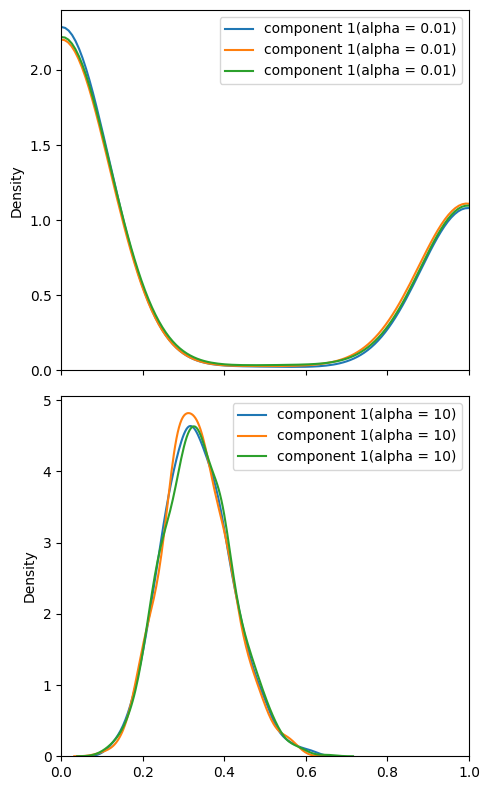

In [6]:
small_alpha, large_alpha = [0.01, 0.01, 0.01], [10, 10, 10]

small_alpha_dirichlet_gen = dirichlet(alpha=small_alpha, seed = 42)
large_alpha_dirichlet_gen = dirichlet(alpha=large_alpha, seed = 42)

small_alpha_dirichlet_vals = small_alpha_dirichlet_gen.rvs(size = 1000)
large_alpha_dirichlet_vals = large_alpha_dirichlet_gen.rvs(size = 1000)

fig, ax = plt.subplots(2, 1, sharex = True, figsize=(5, 8))

for component_idx, alpha_val in enumerate(small_alpha):
    sb.kdeplot(small_alpha_dirichlet_vals[:, component_idx], label = f'component 1(alpha = {alpha_val})', ax = ax[0])
ax[0].set_xlim([0, 1])
ax[0].legend()

for component_idx, alpha_val in enumerate(large_alpha):
    sb.kdeplot(large_alpha_dirichlet_vals[:, component_idx], label = f'component 1(alpha = {alpha_val})', ax = ax[1])
ax[1].legend()

plt.tight_layout()
plt.show()

# Implementation Plan
1. Dataset Creation
2. LDA Class
3. Metrics
4. Visualisation

# Dataset Creation
Idea-1: use openai GPT API to create a bunch of text across various semantic topics, store them in pdfs and then use this set of pdfs as your corpus(train + test).

# LDA Class

## Attributes
1. Hyperparameters
    1. $K$
    2. $\alpha$: $K$-dimensional vector
    3. $\beta$: $V$-dimensional vector
    4. <font color="lightgrey">sampling methods</font>
        1. *initial topic assignment* is using uniform distribution. This could be experimented with.
        2. *topic-assignment post Gibbs-sampling*, the topics are assigned via learned $\theta\,,\,\phi$, which is implemented as `np.random.choice(range(1,K+1,1), probabilities = phi[w.id])`, which is nothing but creating the corresponding cumulative probability array `cumul_w = [phi[w.id][0], phi[w.id][0]+phi[w.id][1], ...,1]`(of length = K) followed by sampling a number in the range `[0,1)` and finding the index of the smallest element in this `cumul_w` array equal to or larger than this random number. Even this kind of sampling can be experimented with.
2. Scalars
    1. $V$: vocabulary size, actually initialised in the `fit` method.
    2. `vocabulary`: set of unique tokens found in the training corpus.
3. Non-scalars
    1. `token to ids`: a token to int mapping dictionary, actually initialised in the `fit` method.
    2. `Z`: topic-assignment is a D-sized list of numpy arrays, each numpy array of shape $N_d \times K$.
    2. after topic-word assignment, matrix $\mathbf{n_{k,w} : K\times V}$
    3. after topic-word assignment, matrix $\mathbf{n_{d, k} : D\times K}$
    4. topic-word probability distribution matrix $\mathbf{\phi} $ of order $K\times V$
    5. document-topic probability distribution matrix $\mathbf{\theta} $ of order $D\times K$

## Methods
1. `preprocess`:
    - *accepts* a list of tokens.
    - *performs* stop word removal, lemmatize, full-stop and other special character removal. <font color="red">utf-8 vs ascii: common format encoding + decoding</font>
    - *returns* a list of processed tokens.
2. `tokenize`: 
    - *accepts*: document text 
    - *performs*: document text $\rightarrow$ sentences $\rightarrow$ tokens $\rightarrow$ `preprocess(tokens)`
        - currently use comma as the delimiter. <font color="grey">create a tokenizer class later on, and set it as the LDA class's attribute</font>
    - *returns* a list of string tokens.
3. `create_token_encoding`:
    - *accepts*: list of valid training documents
    - *performs*:
        - create an empty vocabulary set.
        - for each document d, extract text  $\rightarrow$ `tokenize`  $\rightarrow$ add tokens to vocabulary set.
        - `self.vocabulary = vocabulary_set;self.V = len(self.vocabulary)`
        - take the completed vocabulary set, sort it, create the `self.token_to_ids` by mapping each token to its index in this sorted list.
    - *returns*: `None` 
4. `encode_tokens`:
    - *accepts*: `tokens_list`
    - *performs*: 
        - checks whether `self.vocabulary is not None`. raises an Exception otherwise.
        - use `self.token_to_ids` on the given list of tokens to generate the corresponding sequence of ids.
    - *returns*: `token_ids`
5. `fit`
    1. Arguments:
        - `a list of documents`, each of either `.txt, .doc, .docx or .pdf extension` only, else throw an exception.
            - also throw a warning for those documents from whom no text couldn't be extracted, saying that these will not be processed in the LDA.
            - throw an exception mentioning all those documents who couldn't be opened or read due to inadequate permissions.
        - `test_size` to specify if a test set of documents should be held out from the entire set of given documents.
            - can't be initialised if `test_lod_list is not None`
        - `test_lod_list` to specify a different set of documents that the user wants to be maintained as the test-set list of documents.
            - can't be initialised if `test_size is not None`
        - `n_iterations`: the no. of iterations for which to run the LDA algorithm
        - `metric`: to track and decide convergence. acceptable values = `["frobenius", "kld", "log_likelihood", "perplexity"]`
        - `convergence_threshold`: the threshold by which if the metric doesn't increase(if its supposed to) or decrease(if its supposed to) at least by this threshold then stop the LDA iterations
            - the algorithm **will stop** if threshold-based convergence is reached before `n_iterations` else will stop after `n_iterations`.
        - `patience`: the no. of iterations for which the LDA algorithm is allowed to run, even when the metric has changed in the opposite direction of what was expected. if the metric remains suboptimal w.r.t. the `best_metric_value` even after `patience` no. of iterations, the LDA algorithm is stopped.
    2. Body
        - argument-sanity check
            - `list of documents` (**required**): 
                - `list_of_docs = list(set(list_of_docs))`
                - should be a list of documents + extensions should be valid + all files should be present + all files should be readable.
                - issue a warning for all files who couldn't be read, and who didn't have any text to read.
            - `test_size` (default = 0.2): 
                - should be a float in the open interval `(0,1)`, otherwise raise a ValueError. 
                - raise a ValueError if `test_lod_list` is also passed.
            - `test_lod_list`: 
                - raise a ValueError if `test_size` is also passed.
                - `test_lod_list = list(set(test_lod_list))`
                - should be a list of documents + extensions should be valid + all files should be present + all files should be readable.
                - issue a warning for all files who couldn't be read, and who didn't have any text to read.
                - if the remaining list of valid files is empty, issue a warning saying `"no file from test_lod_list was valid, using test_size = 0.2 instead"`
            - `n_iterations` (default = 10): should be a natural number
            - `metric` (default = `'perplexity'`): one of `['frobenius', 'kld', 'log_likelihood', 'perplexity']`
                - <font color="grey">implement functionality to give a custom metric + arguments to this custom metric function</font>
            - `convergence_threshold` (default = 1e-4): positive number
            - `patience` (default = 0): whole number, shouldn't be higher than `n_iterations`
        - `if test_size is not None and test_lod_list is None`
            - split the list of documents into 2 lists, `test_lod_list = random.choices(list_of_docs, k = max(int(0.2 * len(list_of_docs)),1)`
            - `train_list = list_of_docs - test_lod_list` $\rightarrow$
        - `if test_lod_list is not None and test_size is None`: `train_list = list_of_docs`
        - `create_token_encoding(train_list)`
            - since `K` and `alpha` have already been initialised during object instantiation, initialise `beta` using `self.V`.
            - common heuristic: `beta = [0.01]*self.V`
        - initialise a temp variable `document_token_ids = []`
        - for each document d in `train_list`: `tokenize(doc_text)` $\rightarrow$ `encode_tokens(tokens)` $\rightarrow$ append `token_ids` to `document_token_ids`, thus making `document_token_ids` a `len(train_list) == D` sized list of numpy arrays, each of size $N_d$
        - for each `token_ids` in `document_token_ids`, perform *initial topic assignment*, and store this in `z_d`. append all `z_d` in a list called `Z`
            - after creating `Z`, also create the matrices: $\mathbf{n_{k,w}} \,,\, \mathbf{n_{d,k}} \,,\, \theta_{D\times K}\,,\, \phi_{K\times V}$ 
        - maintain 3 metric-trackers, 2 temp distribution variables and a patience counter: 
            - `curr_metric = [curr_metric_phi, curr_metric_theta]` if `metric in ['frobenius', 'kld']`, **else** `curr_metric = curr_metric` 
            - `curr_phi, curr_theta, prev_phi, prev_theta` (the document-topic and topic-word distributions of the current and previous iterations)
            - `best_metric = [best_metric_phi, best_metric_theta]` if `metric in ['frobenius', 'kld']`, **else** `best_metric = best_metric`  
                - correspondingly store `best_theta`, `best_phi`
            - `patience_counter`
            - `test_set_metric`: is not None if either of `test_size` or `test_lod_list` is not None
        - for the i'th iteration (i: 0 to `self.n_iterations`)
            - iterate through all training documents D
            - for the d'th document, iterate through `document_token_ids[d]`, and within it for each token ID `w` do the following
                - initialise a list `p_wk = [0] * self.K` of probabilities of token-id w belonging to any of the $K$ topics.
                - `k=Z[d][w];n_kw[k][w] -= 1;n_dk[d][k] -= 1`
                - for all `k_ = [1,2,....K]`, `p_wk[k_] = n_dk[d][k_] * ((n_kw[k_][w] + beta[w])/(n_kw[k_][:] + beta).sum())`
                - normalize `p_wk[k_]` as `p_wk[k_] /= p_wk[k_].sum()`
                - `new_k_for_w = np.random.choice(a = np.arange(1,self.K+1), probabilities = p_wk, size = 1)`
                    - `Z[d][w] = new_k_for_w`
                    - `n_kw[new_k_for_w][w] += 1`
                    - `n_dk[d][new_k_for_w] += 1`
                    - `curr_theta[d][new_k_for_w] = (n_dk[d][new_k_for_w] + alpha[new_k_for_w])/(len(document_token_ids[d]) + alpha.sum())`
                    - `curr_phi[new_k_for_w][w] = (n_kw[new_k_for_w][w] + beta[w])/(n_kw[new_k_for_w][w].sum(axis=1) + beta.sum())`
            - after each iteration, calculate the new metrics 
                - train-set metrics
                    - `curr_metric = [metric(prev_phi, curr_phi), metric(prev_theta, curr_theta)]` if `metric in ['frobenius', 'kld']`
                        - `change = curr_metric[0]`
                    - **else** 
                        - `prev_metric = metric(prev_phi, prev_theta, document_token_ids)` 
                        - `curr_metric = metric(curr_phi, curr_theta, document_token_ids)`
                        - `change = curr_metric - prev_metric`
                - test-set metrics
                    - `test_set_curr_theta = predict(doc_names = test_lod_list, phi = curr_phi)`
                    - `test_set_curr_metric = predict_metric(test_lod_list, phi = curr_phi, theta = test_set_curr_theta)`
                    - **Simply record** the test-set metric `test_set_curr_metric` for now, <font color="red">lets make decisions based on it afterwards</font>
            - if `change >= threshold` ==> continue to the next iteration, 
            - else check if `best_metric` was better or worse than `curr_metric`, 
                - if worse then update all `best_*` variables
                - if better, then `patience_counter++`
            - `prev_phi = curr_phi.copy(), prev_theta = curr_theta.copy()`
        - **Break the loop when**: `patience_counter == patience` or `n_iterations` have been performed, whichever is earlier.
    3. ultimately stores the `theta` and `phi` attributes
    4. Returns nothing.
6. `hyperparam_tune`
7. `fit_predict`
8. `predict`
    1. *accepts*:
        1. `doc_names: Union[str, List[str]]`: document name, list of documents, (relative paths for both), OR
        2. `text: str`: text content to predict the topics on
        3. `phi: np.ndarray (default = self.phi)`: of shape $K\times V$
    2. *performs*
        1. sanity checks:
            1. either `doc_names` should be provided or `text` **but not both**
            2. when `doc_names` is provided:
                1. `if type(doc_names) == str`
                    1. check whether `doc_names` is a valid path
                        1. if yes, check extension validity and text-content extraction validity, throw an exception if found invalid
                        2. if no, throw a `FileNotFoundError` exception.
                    2. `token_ids = [encode_tokens(tokenize(text_from_doc_names))]`
                2. `elif type(doc_names) == list` and all elements are valid paths:
                    1. check extension validity and text-content extraction validity
                    2. issue a warning for those documents from whom the text couldn't be extracted
                        1. if no document remains, throw an exception
                    3. for the final `doc_names` list, `token_ids = [encode_tokens(tokenize(text_from_doc)) for doc in doc_names]`
            3. when `text` is provided: `token_ids = [encode_tokens(tokenize(text))]`
            4. topic-word distribution, i.e. $\phi$ should exist. 
        2. initialise the predicted document-topic distribution `theta_test_dk`
        2. `for doc_token_ids in token_ids`, 
            1. `for token_id in doc_token_ids`, use `k_token_id = np.random.choice(a = np.arange(1,K+1,1), probabilities = phi[:][token_id])` to randomly sample a topic to assign to the `token_id` token. update `n_kw_test[k_token_id][token_id], n_dk_test[doc_token_ids][k_token_id]`
            2. update `theta_test_dk[doc_token_ids.index] = n_dk_test[doc_token_ids]/n_dk_test[doc_token_ids].sum()` which is a K-shaped 1d numpy array
    3. *returns*
        1. `theta_test_dk`: the inferred document-topic distribution.


# Metrics

## `frobenius_norm`
1. *accepts* two matrices of the same shape $A\times B$
2. *performs*
    1. sanity check of data type of matrix elements (int/float)
    2. sanity check of order equality of the matrices
    3. use `np.linalg.norm` for now
    4. when implementing custom function:
        1. check for overflow/underflow of $A-B$ <font color="red">How?</font>
        2. perform $||A - B||$ but also check for overflow/underflow.
3. *returns* the frobenium norm of the form $||A - B||$

## `kld`
1. *accepts* two matrices of the same shape $A\times B$
2. *performs*
    1. sanity check of data type of matrix elements (int/float)
    2. sanity check of order equality of the matrices
    3. use `scipy.special.kl_div` for now
3. *returns* the KL divergence.
4. Note: `frobenius_norm()` and `kld()` will be functions outside of the LDA class.

## `log_likelihood(phi, theta, token_ids)`
1. **instance method of LDA class**
2. *accepts*: $\phi, \theta$, `token_ids` = list of list of token ids (n_docs x document_token_ids)
3. *performs*: 
    1. Validity checks
        - $\phi, \theta$ should be 2D
        - `phi.dim1 == theta.dim2, phi.dim2 == lda.V, theta.dim1 == len(token_ids_of_documents)`
    2. initialise `total_log_likelihood = 0`
    3. find `p_dw = theta.dot(phi)` , which will be of the order $D\times V$
    4. for `idx` in `range(len(token_ids))`
        1. `document_token_ids = token_ids[idx]`
        2. `total_log_likelihood += np.log(p_dw[idx][document_token_ids]).sum()`, where the `np.log` gives a `(len(document_token_ids),)` shaped numpy array.
4. *returns*: `total_log_likelihood`, a floating point number.

## `perplexity(phi, theta, token_ids)`
1. **instance method of LDA class**
2. *accepts*: $\phi, \theta$, `token_ids` = list of list of token ids (n_docs x document_token_ids)
3. *performs*: 
    1. Validity checks
        - $\phi, \theta$ should be 2D
        - `phi.dim1 == theta.dim2, phi.dim2 == lda.V, theta.dim1 == len(token_ids_of_documents)`
    2. initialise `total_unnormalised_perplexity = 0, total_tokens = 0`
    3. find `p_dw = theta.dot(phi)` , which will be of the order $D\times V$
    4. for `idx` in `range(len(token_ids))`
        1. `document_token_ids = token_ids[idx]`
        2. `total_unnormalised_perplexity -= np.log(p_dw[idx][document_token_ids]).sum()`, where the `np.log` gives a `(len(document_token_ids),)` shaped numpy array.
        3. `total_tokens += len(document_token_ids)`
    5. `perplexity = np.exp(total_unnormalised_perplexity/total_tokens)`
4. *returns*: `perplexity`, a floating point number.

# Actual Implementation

In [1]:
import os
from typing import List, Union
import warnings
from inspect import signature

from tqdm.notebook import tqdm

import numpy as np
from scipy.special import kl_div

import nltk

import fitz  # PyMuPDF
import docx2python

import matplotlib.pyplot as plt

In [2]:
class Metric:

    def __init__(self, metric: str):
        self.metric = metric
    
    valid_metric_names = ['frobenius', 'kld', 'log_likelihood', 'perplexity']
    valid_mat_dtypes = [
        np.int8, np.int16, np.int32, np.int64,
        np.float16, np.float32, np.float64
    ]

    def __init__(self, metric: str = 'frobenius'):
        # sanity check
        if metric not in self.valid_metric_names:
            raise ValueError(f"metric {metric} not in valid metrics "
                             f"{self.valid_metric_names}")
        
        self.metric_name = metric
        self.metric = None
        if metric == 'frobenius':
            self.metric = self.frobenius
        elif metric == 'kld':
            self.metric = self.kld
        elif metric == 'log_likelihood':
            self.metric = self.log_likelihood
        else:
            self.metric = self.perplexity
        
    def __call__(self, **kwargs):
        if self.metric_name in ('frobenius', 'kld'):
            exception_str = ""
            if 'prev_mat' not in kwargs:
                exception_str += "'prev_mat' not provided;"
            if 'new_mat' not in kwargs:
                exception_str += "'new_mat' not provided;"
            if exception_str:
                raise ValueError(exception_str)
            return self.metric(
                prev_mat=kwargs['prev_mat'], 
                new_mat=kwargs['new_mat']
            )
        exception_str = ""
        for arg_name in ['theta', 'phi', 'document_tokens']:
            if arg_name not in kwargs:
                exception_str += f"{arg_name} not provided;"
        if exception_str:
            raise ValueError(exception_str)
        return self.metric(theta = kwargs['theta'], 
                           phi = kwargs['phi'],
                           document_tokens = kwargs['document_tokens'])
    
    def sanity_check_matrix(self, mat: np.ndarray):
        """
        Checks if the input matrix `mat` is a valid NumPy 2D array with a supported data type.

        Args:
            mat (np.ndarray): The matrix to check.

        Returns:
            bool: True if the matrix is a NumPy 2D array and its data type is in the `self.valid_mat_dtypes` list, False otherwise.
        """
        return isinstance(mat, np.ndarray) and (mat.ndim == 2) and \
                mat.dtype in self.valid_mat_dtypes
    
    def sanity_check_matrix_pair(self, prev_mat: np.ndarray, new_mat: np.ndarray):
        """
        Validates two matrices for basic structural requirements and mutual compatibility.

        1. Checks if both matrices are sane
        2. have the same shape

        Args:
            mat1 (np.ndarray): First matrix to validate
            mat2 (np.ndarray): Second matrix to validate

        Returns:
            bool: True if both matrices are sane and have the same shape,
                  False otherwise

        Raises:
            ValueError: If either matrix is not sane or their shape doesn't 
                        match
        """

        # sanity check: 
        # 1. if even one of (prev_mat, new_mat) is not sane, OR
        # 2. they have different order, the pair is not sane
        if not self.sanity_check_matrix(prev_mat) or \
            not self.sanity_check_matrix(new_mat) or \
            prev_mat.shape != new_mat.shape:
            raise ValueError(
                "mismatch between prev_mat and new_mat args.\n"
                "Expects both to be 2D numpy arrays with the same shape."
            )
        return True
    
    def frobenius(self, prev_mat: np.ndarray, new_mat: np.ndarray): 
        """
        Evaluates the Frobenius norm of the two given matrices, after
        checking their pairwise sanity

        Frobenius norm = ||A - B||_F = sqrt(
                                sum over rows i and columns j(a_ij - b_ij)^2)

        Args:
            mat1 (np.ndarray): matrix B
            mat2 (np.ndarray): matrix A

        Returns:
            np.float64: Frobenius norm as per the above formula

        Raises:
            ValueError: If either matrix is not sane or their shape doesn't 
                        match, i.e. frobenius norm can't be computed
        """
        self.sanity_check_matrix_pair(prev_mat, new_mat)
        return np.linalg.norm(new_mat - prev_mat)
    
    def kld(self, prev_mat: np.ndarray, new_mat: np.ndarray): 
        """
        Evaluates the KL Divergence of the two given matrices, after
        checking their pairwise sanity

        KL Divergence = sum over i rows j columns(a_ijlog(a_ij/b_ij))

        Args:
            mat1 (np.ndarray): matrix B
            mat2 (np.ndarray): matrix A

        Returns:
            np.float64: KL Divergence as per the above formula

        Raises:
            ValueError: If either matrix is not sane or their shape doesn't 
                        match or , i.e. frobenius norm can't be computed
        """
        self.sanity_check_matrix_pair(prev_mat, new_mat)

        prev_mat_copy = prev_mat.copy()
        prev_mat_copy = np.clip(prev_mat_copy, 1e-5, None)

        # the order matters because kl_div(a, b) = a log (a/b)  - a + b
        # , hence a should be the new matrix
        return kl_div(new_mat, prev_mat_copy).sum()

    def log_likelihood(self, 
                       theta: np.ndarray, phi: np.ndarray, 
                       document_tokens): 
        """
        Evaluates the log likelihood given the topic-word distribution(phi),
        document-topic distribution(theta) and token-list for all documents
        used to create theta.

        expects theta: D x K, phi: K x V, len(token-list) = D, 
        len(token_list[d]) = N_d (the no. of tokens in d'th document)
        D: no. of documents, K: no. of topics, V: vocabulary size

        Args:
            theta (np.ndarray): matrix of order D x K
            phi (np.ndarray): matrix of order K x V
            document_tokens: list of list of ints

        Returns:
            np.float64: Log likelihood of the topic model described by the above
                        parameters

        Raises:
            ValueError: If either matrix is not sane or their shape doesn't 
                        match or , i.e. frobenius norm can't be computed
        """
        self.sanity_check_matrix(theta)
        self.sanity_check_matrix(phi)

        D, K = theta.shape
        K1, V = phi.shape
        D1 = len(document_tokens)
        V1_set = set().union(*document_tokens)

        assert K == K1, "no. of topics mismatch between phi and theta"
        assert D == D1, "no. of documents mismatch between theta and "\
                        "document tokens"
        assert V1_set.issubset(set(np.arange(V))), f"following tokens not found"\
                        f" in training vocabulary {V1_set - set(np.arange(V))} "
        
        # find the sum of theta_dk * phi_kw, over all k values
        W_dn = theta.dot(phi) # D x V

        # convert all token-lists to np.ndarray
        document_tokens = [
            np.array(tokens) if not isinstance(tokens, np.ndarray) else tokens
            for tokens in document_tokens
        ]

        # for d'th doc, select the W_dn values of 
        # each token-occurrence found in it
        # if tokens[d] = [2,89,100, 5] and W_dn[2] = 0.1, W_dn[5] = 0.01, 
        # W_dn[89] = 0.03, W_dn[100] = 0.9, this will return [0.1, 0.03, 0.9, 0.01]
        p_w = [W_dn[i, document_tokens[i]] for i in range(D)]

        # find the document with the longest tokens list.
        # this will be used to pad other token lists.
        max_sz = max(p_w_i.size for p_w_i in p_w)

        # pad all document-wise token lists so that a numpy array can be created.
        # use pad value = 1 as log(1) = 0, so it won't change the log-likelihood
        # value
        p_w = np.stack(
            [np.pad(p_w_i, pad_width=(0, max_sz - p_w_i.size), mode='constant',
                    constant_values=1)
            for p_w_i in p_w]
        )

        # np.log safety: replace all 0s with a small positive constant
        dx = 1e-4
        p_w[p_w == 0] = dx

        log_p_w = np.log(p_w)
        return log_p_w.sum()

    def perplexity(self, 
                       theta: np.ndarray, phi: np.ndarray, 
                       document_tokens): 
        """
        Evaluates the perplexity given the topic-word distribution(phi),
        document-topic distribution(theta) and token-list for all documents
        used to create theta.

        expects theta: D x K, phi: K x V, len(token-list) = D, 
        len(token_list[d]) = N_d (the no. of tokens in d'th document)
        D: no. of documents, K: no. of topics, V: vocabulary size

        Args:
            theta (np.ndarray): matrix of order D x K
            phi (np.ndarray): matrix of order K x V
            document_tokens: list of list of ints

        Returns:
            np.float64: perplexity of the topic model described by the above
                        parameters

        Raises:
            ValueError: If either matrix is not sane or their shape doesn't 
                        match or , i.e. frobenius norm can't be computed
        """
        self.sanity_check_matrix(theta)
        self.sanity_check_matrix(phi)

        D, K = theta.shape
        K1, V = phi.shape
        D1 = len(document_tokens)
        V1_set = set().union(*document_tokens)

        assert K == K1, "no. of topics mismatch between phi and theta"
        assert D == D1, "no. of documents mismatch between theta and "\
                        "document tokens"
        assert V1_set.issubset(set(np.arange(V))), f"following tokens not found"\
                        f" in training vocabulary {V1_set - set(np.arange(V))} "
        
        # find the sum of theta_dk * phi_kw, over all k values
        W_dn = theta.dot(phi) # D x V

        # convert all token-lists to np.ndarray
        document_tokens = [
            np.array(tokens) if not isinstance(tokens, np.ndarray) else tokens
            for tokens in document_tokens
        ]

        # for d'th doc, select the W_dn values of 
        # each token-occurrence found in it
        # if tokens[d] = [2,89,100, 5] and W_dn[2] = 0.1, W_dn[5] = 0.01, 
        # W_dn[89] = 0.03, W_dn[100] = 0.9, this will return [0.1, 0.03, 0.9, 0.01]
        p_w = [W_dn[i, document_tokens[i]] for i in range(D)]

        # obtain the [N_d...] list, i.e. no. of tokens for each document
        N_d_values = [doc_tokens.size for doc_tokens in document_tokens]
        N_d_sum = sum(N_d_values)

        # find the document with the longest tokens list.
        # this will be used to pad other token lists.
        max_sz = max(p_w_i.size for p_w_i in p_w)

        # pad all document-wise token lists so that a numpy array can be created.
        # use pad value = 1 as log(1) = 0, so it won't change the log-likelihood
        # value
        p_w = np.stack(
            [np.pad(p_w_i, pad_width=(0, max_sz - p_w_i.size), mode='constant',
                    constant_values=1)
            for p_w_i in p_w]
        )

        # np.log safety: replace all 0s with a small positive constant
        dx = 1e-4
        p_w[p_w == 0] = dx
        
        return np.exp(-np.log(p_w).sum()/N_d_sum)
    def signature(self):
        return signature(self.metric)

In [46]:
class LDA:
    
    valid_extensions = [".pdf", ".doc", ".docx", ".txt"]
    stop_words = set(nltk.corpus.stopwords.words('english'))
    valid_metrics = ['frobenius', 'kld', 'log_likelihood', 'perplexity']

    def __init__(self, K, alpha = None):
        self.K = K
        self.alpha = np.array(alpha if alpha else [round(50/K,5)]*K)
        self.beta = None # initialised in self.fit(...)

        self.vocabulary = set()
        self.V = None
        self.token_to_id = {}
        self.id_to_token = {}

        self.metric = None

    
    def preprocess(self, tokens: List[str]):
        """
        """
        assert isinstance(tokens, List), "tokens should be of type List"
        assert all(isinstance(item, str) for item in tokens), "each token should \
            be of type str"

        final_tokens = []
        for token in tokens:
            if not isinstance(token, str):
                raise ValueError(f"Expected type str, found token {token} with "
                                 f"type {type(token)}")
            token = token.lower().strip()
            if token.lower() not in self.stop_words and len(token) > 0:
                # TODO: lemmatisation
                final_tokens.append(token.lower())
        return final_tokens
    
    def tokenize(self, document_text: str):
        """
        """
        # argument type assertion
        assert isinstance(document_text, str), "document_text expected to be str"
        
        sentences = document_text.split(".")
        tokens = []
        for sent in sentences:
            tokens.extend(sent.split(" "))
        processed_tokens = self.preprocess(tokens)
        return processed_tokens
    
    def open_pdf(self, doc_path: str) -> str:

        # confirm that the given path is indeed a pdf file
        assert(doc_path.endswith('.pdf'))
        
        # the list of tokens to return
        tokens = []
        
        try:
            # Open a PDF document
            pdf_document = fitz.open(doc_path)

            # Get the number of pages in the document
            num_pages = pdf_document.page_count

            # Extract text from all pages
            for page_num in range(num_pages):
                page = pdf_document.load_page(page_num)
                text = page.get_text()
                tokens.extend(self.tokenize(text))
        except Exception as e:
            return []
        return tokens
    
    def open_doc(self, doc_path: str):
        
        # confirm that the given path is indeed a docpdf file
        assert doc_path.endswith('.doc')
        
        # the list of tokens to return
        tokens = []
        
        try:
            # TODO: read and tokenize the given doc file
            pass
        except Exception as e:
            return []
        return tokens

    def open_docx(self, doc_path: str):
        """
        """
        
        # confirm that the given path is indeed a docx file
        assert doc_path.endswith('.docx')
        
        # the list of tokens to return
        tokens = []
        
        try:
            docx_content_ptr = docx2python.docx2python(doc_path)
            docx_content = docx_content_ptr.text
            docx_content_ptr.close()
            tokens.extend(self.tokenize(docx_content))
        except Exception as e:
            return []
        return tokens
    
    def open_txt(self, doc_path: str):
        
        # confirm that the given path is indeed a txt file
        assert doc_path.endswith('.txt')
        
        # the list of tokens to return
        tokens = []
        
        try:
            # TODO: read and tokenize the given txt file
            fp = open(doc_path, 'r')
            content = ""
            for line in fp.readlines():
                content += line.strip()
            tokens.extend(self.tokenize(content))
        except Exception as e:
            return []
        return tokens
    
    def open_document(self, doc_path: str):
        """
        """
        # argument sanity check
        assert isinstance(doc_path, str)

        if not os.path.exists(doc_path):
            raise FileNotFoundError(f"File {doc_path} doesn't exist.")
        file_readers = [self.open_pdf, self.open_doc, 
                        self.open_docx, self.open_txt]
        for idx, valid_extension in enumerate(self.valid_extensions):
            if doc_path.endswith(valid_extension):
                return file_readers[idx](doc_path)
        raise ValueError(f"Provided file {doc_path} should be amongst the valid"
                         f" extensions {self.valid_extensions}")

    def create_token_encoding(self, list_of_doc_names: List[str]):
        """
        """
        # call the <list of document names> sanity checker
        sane_list_of_docs = self.sanity_check_documents_list(list_of_doc_names)
        if len(sane_list_of_docs) == 0:
            raise Exception("No list of documents remain, examine the provided"
            "documents")
        for d, doc_name in enumerate(list_of_doc_names):

            # open the document and tokenize it
            doc_tokens = self.open_document(doc_name)

            # update the vocabulary with the tokens 
            # obtained from the current document
            self.vocabulary.update(set(doc_tokens))
        
        # vocabulary size
        self.V = len(self.vocabulary)
        
        # create the token to id map
        for idx, token in enumerate(sorted(list(self.vocabulary))):
            self.token_to_id[token] = idx
            self.id_to_token[idx] = token
    
    def encode_tokens(self, tokens: List[str]):
        """
        """
        # TODO: replace with SIMD
        token_ids = []

        for token in tokens:
            if token in self.token_to_id:
                token_ids.append(self.token_to_id[token])
        return np.array(token_ids)

    def decode_ids(self, ids: List[int]):
        """
        """
        # assert 

        # TODO: replace with SIMD
        tokens = []

        for id in ids:
            if id in self.id_to_token:
                tokens.append(self.id_to_token[id])
        return tokens
    
    def sanity_check_documents_list(self, documents_list: List[str]):
        """
        """
        sane_list = []
        for doc_name in documents_list:
            if os.path.exists(doc_name):
                if not any(
                    doc_name.endswith(ext) for ext in self.valid_extensions):
                    warnings.warn(f"Document {doc_name} isn't of a valid extension."
                                  f"Please only provide documents of the "
                                  f"following list of valid extensions: "
                                  f"{self.valid_extensions}")
                else:
                    # document exists and is of a valid extension

                    # lets see if its content is extractable and tokenizable
                    token_ids = self.open_document(doc_name)
                    if len(token_ids) == 0:
                        # no token could be extracted
                        warnings.warn(f"Ignoring {doc_name} as no tokens "
                                      f"were extracted")
                    else:
                        sane_list.append(doc_name)
            else:
                warnings.warn(f"Document {doc_name} not found, will be ignored")
        if len(sane_list) == 0:
            raise ValueError("No Sane document found, "
                            "please check your documents.")
        return sane_list
    
    def fit(self, documents_list: List[str], test_size = None, 
            test_docs_list = None , n_iterations = 100, patience = None,
            metric = 'frobenius', convergence_thresh = 1e-4):

        print("Checking sanity of documents list...")
        # sanity check for documents_list
        documents_list = self.sanity_check_documents_list(documents_list)
        print("Documents list passed sanity check.")
        
        # sanity check for test_size + test_docs_list
        # TODO: wrap the code below into 
        # self.sanity_check_test_params(test_size, test_docs_list)
        if test_size is not None and test_docs_list is not None:
            raise ValueError("Only one of test_size or test_docs_list can be\
                              provided")
        if test_docs_list is not None:
            try:
                test_docs_list = self.sanity_check_documents_list(test_docs_list)
            except ValueError as _:
                warnings.warn("No sane test document was found," 
                              " using test_size = 0.2")
                test_docs_list = None
                test_size = 0.2
        
        # allow till test_size = 0.4
        if test_size:
            if test_size > 0.4:
                raise ValueError("test_size exceeded 40%, i.e. 0.4. \
                                provide a smaller fraction")
            if test_size < 0:
                raise ValueError("Cannot provide negative test set size")
        
        print("test_size/test_docs_list passed sanity check.")

        # TODO: sanity checks on n_iterations, metric, and convergence_thresh
        if not isinstance(n_iterations, int):
            raise ValueError(f"n_iterations should be of type int, "
                             f"provided of type {type(n_iterations)}")
        if not isinstance(metric, str):
            raise ValueError(f"metric should be of type str, "
                             f"provided of type {type(metric)}")
        else:
            if metric not in self.valid_metrics:
                raise ValueError(f"metric should be of {self.valid_metrics}, "
                                 f"provided {metric}")
        
        valid_thresh_dtype = [int, float]
        if not any(isinstance(convergence_thresh, type_val) 
                   for type_val in valid_thresh_dtype):
            raise ValueError(f"convergence_thresh should be of "
                             f"type {valid_thresh_dtype}, provided of "
                             f"type {type(convergence_thresh)}")
        
        self.metric = Metric(metric)
        print(f"Initialised metric object instance {metric}.")

        # locate your train and test-set list of documents
        sane_test_docs_list, sane_train_docs_list, is_test = [], [], False
        if test_size is not None:
            num_test_docs = int(test_size*len(documents_list))
            sane_test_docs_list = np.random.choice(a = num_test_docs, 
                                                   size = num_test_docs,
                                                   replace=False)
            sane_train_docs_list = [doc_name for doc_name in documents_list
                                    if doc_name not in sane_test_docs_list]
            is_test = True
        elif test_docs_list is not None:
            sane_test_docs_list = test_docs_list
            sane_train_docs_list = documents_list
            is_test = True
        else:
            # no test set
            sane_train_docs_list = documents_list
        
        self.create_token_encoding(sane_train_docs_list)
        print(f"Finished creating token encodings. Found {self.V} tokens in vocabulary.")

        # the above will initialise vocabulary, hence V
        # so, the beta can now be initialised
        self.beta = np.full(shape = (self.K, self.V), fill_value=0.01)

        topics = np.arange(1, self.K+1)
        document_token_ids, Z = [], []
        n_kw = np.zeros((self.K, self.V))
        n_dk = np.zeros((len(sane_train_docs_list), self.K))
        prev_theta = np.zeros((len(sane_train_docs_list), self.K))
        new_theta = np.zeros((len(sane_train_docs_list), self.K))
        
        # initial topic assignment + updating matrices
        for d in tqdm(range(len(sane_train_docs_list)), "Initial topic assignment..."):
            doc_name = sane_train_docs_list[d]
            token_ids = self.encode_tokens(self.open_document(doc_name))
            document_token_ids.append(token_ids)
            z_d = np.random.choice(
                a = np.arange(1, self.K+1,1),
                size = token_ids.shape[0],
                replace=True
            )
            Z.append(z_d)
            
            topic_counts = np.zeros_like(topics)
            unique_topics, counts = np.unique(z_d, return_counts=True)
            mask = np.isin(topics, unique_topics)
            indices = np.searchsorted(unique_topics, topics)
            topic_counts[mask] = counts[indices]
            n_dk[d] = topic_counts
            
            prev_theta[d] = (n_dk[d] + self.alpha)/(token_ids.shape[0] + \
                                                    self.alpha.sum())
            
            topic_token_id_counts = np.zeros_like(n_kw)
            np.add.at(topic_token_id_counts, (z_d-1, token_ids), 1)
            n_kw += topic_token_id_counts

        prev_phi = (n_kw + self.beta)/((n_kw + self.beta).sum(axis=1)[:, np.newaxis])
        new_phi = None

        metric_log = []
        metric_val = [0, 0] if metric in ['frobenius', 'kld'] else 0
        best_metric = [0, 0] if metric in ['frobenius', 'kld'] else 0
        patience_counter = 0
        iter = 0
        lda_pbar = tqdm(total = n_iterations, desc="LDA Iterations...")
        while iter < n_iterations and (
            patience_counter != patience if patience
            else True):
            for d, token_ids in enumerate(document_token_ids):
                for w_idx, w in enumerate(token_ids):
                    k = Z[d][w_idx]

                    assert n_kw[k-1][w] > 0 , f"word {self.id_to_token[w]} at "\
                            f"index = {w_idx} not in document {sane_train_docs_list[d]}, "\
                            f"k = {k}, "\
                            f"n_kw[k-1][w] = {n_kw[k-1][w]}, Z_[d] = {Z[d]}"
                    assert n_dk[d][k-1] > 0 , f"topic {k} not "\
                            f"in document {d}, n_dk[d][k-1] = {n_dk[d][k-1]}"
                    
                    # un-assignment
                    n_kw[k-1][w] -= 1
                    n_dk[d][k-1] -= 1

                    p_wk = n_dk[d] * ((np.clip(n_kw[:, w] + self.beta[:, w], 1e-4, None))/np.clip((n_kw[:, w] + self.beta[:, w]).sum(), 1e-4, None))
                    p_wk /= np.clip(p_wk.sum(), 1e-4, None)

                    # re-assignment
                    try:
                        k_new = np.random.choice(topics,p = p_wk)
                        n_kw[k_new-1][w] += 1
                        n_dk[d][k_new-1] += 1
                        Z[d][w_idx] = k_new
                    except ValueError as ve:
                        print("original topic assigned = ", Z[d][w_idx], "\n", p_wk, "\n", p_wk.sum(), "\n\n", ve)
                new_theta[d] = (n_dk[d] + self.alpha)/(token_ids.shape[0] + \
                                                    self.alpha.sum())
            new_phi = (n_kw + self.beta)/((n_kw + self.beta).sum(axis=1)[:, np.newaxis])
            change = None
            if metric in ['frobenius', 'kld']:
                metric_val[0] = self.metric(
                    prev_mat = prev_phi, new_mat = new_phi)
                metric_val[1] = self.metric(
                    prev_mat = prev_theta, new_mat = new_theta)
                change = metric_val[0]
                metric_log.append(change)
                # TODO: log metric_val
            else:
                prev_metric = self.metric(
                    phi = prev_phi, theta = prev_theta, 
                    document_tokens = document_token_ids)
                new_metric = self.metric(
                    phi = new_phi, theta = new_theta, 
                    document_tokens = document_token_ids)
                change = new_metric - prev_metric
            if patience and change < convergence_thresh:
                # best_metric
                patience_counter += 1

            # save the newly computed theta and phi values
            self.theta = new_theta
            self.phi = new_phi

            # advance to next iteration
            iter += 1
            lda_pbar.update(1)

        for iter in range(len(metric_log)):
            print(f"Iter {iter+1}, contents(metric = {metric}) = {metric_log[iter]}\n",
                  file = open("logs.txt", "a+"))
        np.save('theta.npy', self.theta)
        np.save('phi.npy', self.phi)
        print("Finished writing logs.")

        fig, ax = plt.subplots()
        yaxis_name = f'change in {metric}' if metric in ['frobenius', 'kld'] else ''
        ax.set_xlabel('Iterations');ax.set_ylabel(yaxis_name)
        ax.plot(range(len(metric_log)), metric_log)
        return fig

Checking sanity of documents list...
Documents list passed sanity check.
test_size/test_docs_list passed sanity check.
Initialised metric object instance frobenius.
Finished creating token encodings. Found 1761 tokens in vocabulary.


Initial topic assignment...:   0%|          | 0/6 [00:00<?, ?it/s]

LDA Iterations...:   0%|          | 0/165 [00:00<?, ?it/s]

Finished writing logs.


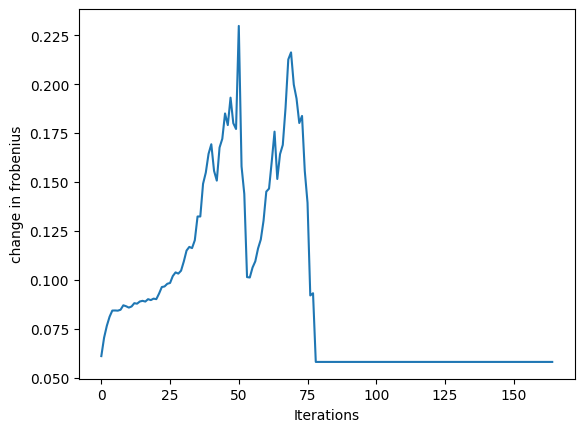

In [47]:
K = 3
lda_model = LDA(K = K)

documents = [os.path.join("./docs", x) for x in os.listdir("./docs")]

for log_file in ["logs.txt", "phi.npy", "theta.npy"]:
    if os.path.exists(log_file):
        os.remove(log_file)

metric_plot = lda_model.fit(
    documents_list=documents,
    n_iterations=165
)
plt.show()

In [48]:
phi, theta = np.load('phi.npy'), np.load('theta.npy')
print(phi)

[[0.00056786 0.00056786 0.00056786 ... 0.00056786 0.00056786 0.00056786]
 [0.00056786 0.00056786 0.00056786 ... 0.00056786 0.00056786 0.00056786]
 [0.00161581 0.00032574 0.00064826 ... 0.00484098 0.00064826 0.00064826]]


In [49]:
print(theta)

[[0.02645503 0.02645503 0.94708994]
 [0.02436648 0.02436648 0.95126705]
 [0.05241091 0.05241091 0.89517818]
 [0.02714441 0.02714441 0.94571117]
 [0.04604052 0.04604052 0.90791895]
 [0.02150538 0.02150538 0.95698924]]


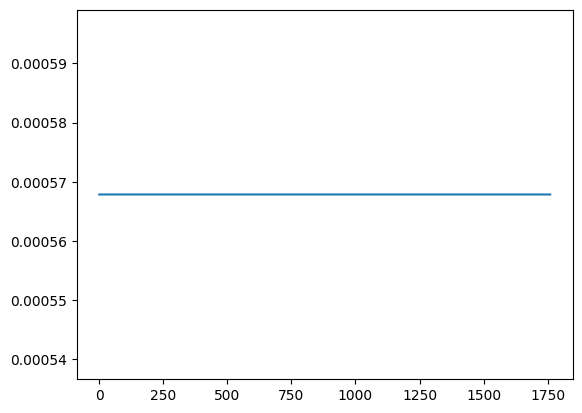

In [50]:
plt.plot(np.arange(phi[0, :].shape[0]), phi[0, :])
plt.show()

In [52]:
np.argsort(phi[2, :])[-30:][::-1], lda_model.decode_ids(np.argsort(phi[2, :])[-30:][::-1])

(array([1151,  748,  979,  865,  559,  168, 1758,  838, 1654,  864,   23,
         384, 1124, 1081, 1270,  784, 1727, 1031, 1653, 1171,  861, 1711,
        1231, 1336, 1237, 1172, 1123, 1728, 1497, 1017]),
 ['needs',
  'ford',
  'kendrick',
  'human',
  'drake',
  'also',
  '\u200b',
  'hierarchy',
  'understanding',
  'href="https://www',
  '###',
  'company',
  'modern',
  "maslow's",
  'practices',
  'ge',
  'wikipedia',
  'like',
  'understand',
  'often',
  'href="https://en',
  'welch',
  'personal',
  'rap',
  'physics',
  'one',
  'model',
  'within',
  'social',
  'level'])

In [39]:
phi[2, np.argsort(phi[2, :])]

array([0.00054113, 0.00054113, 0.00054113, ..., 0.00054113, 0.00054113,
       0.00054113])

In [ ]:
np.cumsum()

array([ 0,  1,  3,  6, 10])